# 🚇 NammaPred — Bengaluru Metro Intelligence System

## 📌 Project Overview
An end-to-end Machine Learning project to predict 
passenger crowd levels across Purple, Green and Yellow 
metro lines in Bengaluru using real-world inspired data.

---

## 🎯 Problem Statement
Bengaluru Metro (BMRCL) faces overcrowding during peak hours 
at key stations like Majestic, MG Road and Indiranagar. 
This project predicts passenger count and crowd level 
to help metro authorities optimize train frequency 
and reduce overcrowding.

---

## 📊 Dataset
- Total Rows     : 3000
- Total Columns  : 21
- Metro Lines    : Purple, Green, Yellow
- Stations       : 40+ real BMRCL stations
- Source         : Synthetic data based on real 
                   BMRCL station network and 
                   realistic ridership patterns

---

## 🔧 Tech Stack
| Tool | Purpose |
|---|---|
| Python | Programming Language |
| Pandas | Data Manipulation |
| NumPy | Numerical Computing |
| Matplotlib | Data Visualization |
| Seaborn | Statistical Plots |
| Scikit-learn | ML Algorithms |
| XGBoost | Gradient Boosting |
| Streamlit | Web Deployment |
| GitHub | Version Control |

---

## 🔄 Project Pipeline

## 📦 Step 1 — Import Libraries

In [1]:
import pandas as pd

## 📂 Step 2 — Load Dataset

In [2]:
df = pd.read_csv(r'C:\Users\nandh\Downloads\Bengaluru_Metro_Final.csv')

In [3]:
df

,station_name,metro_line,hour_of_day,day_of_week,month,is_weekend,is_holiday,temperature_c,is_raining,nearby_it_park,...,is_peak_hour,time_category,is_off_day,passenger_count,footfall_category,station_type,delay_minutes,wifi_available,date,fare_inr
0,Dasarahalli,Green,20.0,Friday,June,No,No,32.6,No,No,...,No,Night,No,993.0,Medium,Regular,0.0,No,2024-06-01,10.0
1,National College,Green,13.0,Sunday,May,Yes,No,26.1,No,No,...,No,Midday,Yes,1271.0,Medium,Regular,5.0,No,2025-05-01,NaN
2,Yeshwanthpur,Green,NaN,Tuesday,December,No,No,23.4,No,Yes,...,No,Midday,No,1254.0,Medium,Regular,2.0,Yes,2023-12-19,20.0
3,RV Road,Yellow,20.0,Monday,September,No,No,24.8,No,No,...,No,Night,No,886.0,Medium,Interchange,0.0,No,2024-09-05,NaN
4,Jalahalli,Green,20.0,Sunday,June,Yes,No,23.2,Yes,No,...,No,Night,Yes,450.0,Low,Regular,0.0,No,2024-06-13,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,Whitefield,Purple,15.0,Saturday,June,Yes,No,NaN,Yes,Yes,...,No,Evening,Yes,595.0,Low,Regular,2.0,No,2024-06-05,20.0
2996,Attiguppe,Purple,12.0,Sunday,March,Yes,No,22.5,No,No,...,No,Midday,Yes,1224.0,Medium,Regular,0.0,No,2024-03-26,40.0
2997,Swami Vivekananda Road,Purple,15.0,Wednesday,August,No,No,20.7,No,No,...,No,Evening,No,NaN,Medium,Regular,0.0,No,2025-08-03,20.0
2998,National College,Green,17.0,Thursday,December,No,No,24.2,No,No,...,Yes,Evening,No,3968.0,High,Regular,0.0,No,2024-12-23,25.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   station_name         2887 non-null   object 
 1   metro_line           2923 non-null   object 
 2   hour_of_day          2940 non-null   float64
 3   day_of_week          2940 non-null   object 
 4   month                2940 non-null   object 
 5   is_weekend           2910 non-null   object 
 6   is_holiday           2839 non-null   object 
 7   temperature_c        2733 non-null   float64
 8   is_raining           2792 non-null   object 
 9   nearby_it_park       2881 non-null   object 
 10  train_frequency_min  2810 non-null   float64
 11  is_peak_hour         2940 non-null   object 
 12  time_category        2940 non-null   object 
 13  is_off_day           2940 non-null   object 
 14  passenger_count      2822 non-null   float64
 15  footfall_category    2853 non-null   o

In [5]:
print("BEFORE CLEANING")
print("Shape:", df.shape)
print("Null values:\n", df.isna().sum())

BEFORE CLEANING
Shape: (3000, 21)
Null values:
 station_name           113
metro_line              77
hour_of_day             60
day_of_week             60
month                   60
is_weekend              90
is_holiday             161
temperature_c          267
is_raining             208
nearby_it_park         119
train_frequency_min    190
is_peak_hour            60
time_category           60
is_off_day              60
passenger_count        178
footfall_category      147
station_type           113
delay_minutes           90
wifi_available         114
date                    60
fare_inr               114
dtype: int64


In [6]:
df.columns

Index(['station_name', 'metro_line', 'hour_of_day', 'day_of_week', 'month',
       'is_weekend', 'is_holiday', 'temperature_c', 'is_raining',
       'nearby_it_park', 'train_frequency_min', 'is_peak_hour',
       'time_category', 'is_off_day', 'passenger_count', 'footfall_category',
       'station_type', 'delay_minutes', 'wifi_available', 'date', 'fare_inr'],
      dtype='object')

In [7]:
df.describe()

,hour_of_day,temperature_c,train_frequency_min,passenger_count,delay_minutes,fare_inr
count,2940.000000,2733.000000,2810.000000,2822.000000,2910.000000,2886.000000
mean,13.903741,27.061873,5.071174,1825.934798,1.455670,24.085239
std,4.922321,2.927944,1.846337,1240.747013,2.342002,9.569323
min,6.000000,15.800000,3.000000,402.000000,0.000000,10.000000
25%,10.000000,25.200000,3.000000,921.000000,0.000000,20.000000
50%,14.000000,27.000000,5.000000,1273.000000,0.000000,20.000000
75%,18.000000,29.100000,5.000000,2391.000000,2.000000,30.000000
max,22.000000,35.800000,8.000000,5370.000000,10.000000,50.000000


## 🧹 Data Cleaning

In [8]:
df = df.dropna(subset=['station_name', 'metro_line', 'passenger_count'])
df.rename(columns={'footfall_category': 'Passenger_Crowd_Level'}, inplace=True)

C:\Users\nandh\AppData\Local\Temp\ipykernel_5864\202851176.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={'footfall_category': 'Passenger_Crowd_Level'}, inplace=True)


In [9]:
df

,station_name,metro_line,hour_of_day,day_of_week,month,is_weekend,is_holiday,temperature_c,is_raining,nearby_it_park,...,is_peak_hour,time_category,is_off_day,passenger_count,Passenger_Crowd_Level,station_type,delay_minutes,wifi_available,date,fare_inr
0,Dasarahalli,Green,20.0,Friday,June,No,No,32.6,No,No,...,No,Night,No,993.0,Medium,Regular,0.0,No,2024-06-01,10.0
1,National College,Green,13.0,Sunday,May,Yes,No,26.1,No,No,...,No,Midday,Yes,1271.0,Medium,Regular,5.0,No,2025-05-01,NaN
2,Yeshwanthpur,Green,NaN,Tuesday,December,No,No,23.4,No,Yes,...,No,Midday,No,1254.0,Medium,Regular,2.0,Yes,2023-12-19,20.0
3,RV Road,Yellow,20.0,Monday,September,No,No,24.8,No,No,...,No,Night,No,886.0,Medium,Interchange,0.0,No,2024-09-05,NaN
4,Jalahalli,Green,20.0,Sunday,June,Yes,No,23.2,Yes,No,...,No,Night,Yes,450.0,Low,Regular,0.0,No,2024-06-13,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2994,Chickpete,Green,14.0,Thursday,March,No,No,27.1,No,No,...,No,Evening,No,1103.0,Medium,Regular,0.0,No,2023-03-16,20.0
2995,Whitefield,Purple,15.0,Saturday,June,Yes,No,NaN,Yes,Yes,...,No,Evening,Yes,595.0,Low,Regular,2.0,No,2024-06-05,20.0
2996,Attiguppe,Purple,12.0,Sunday,March,Yes,No,22.5,No,No,...,No,Midday,Yes,1224.0,Medium,Regular,0.0,No,2024-03-26,40.0
2998,National College,Green,17.0,Thursday,December,No,No,24.2,No,No,...,Yes,Evening,No,3968.0,High,Regular,0.0,No,2024-12-23,25.0


In [10]:
df.shape

(2643, 21)

In [11]:
mean_cols = ['temperature_c']

for col in mean_cols:
    df[col] = df[col].fillna(df[col].mean())
    print(f"Filled {col} with mean: {df[col].mean():}")

Filled temperature_c with mean: 27.0807293825114


C:\Users\nandh\AppData\Local\Temp\ipykernel_5864\385065024.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].fillna(df[col].mean())


In [12]:
median_cols = ['train_frequency_min','delay_minutes','fare_inr','passenger_count']

for col in median_cols:
    df[col] = df[col].fillna(df[col].median())
    print(f"Filled {col} with median: {df[col].median():.2f}")

# Hour of day — Median + convert to int
df['hour_of_day'] = df['hour_of_day'].fillna(df['hour_of_day'].median()).astype(int)
print(f"Filled hour_of_day with median: {df['hour_of_day'].median()}")

Filled train_frequency_min with median: 5.00
Filled delay_minutes with median: 0.00
Filled fare_inr with median: 20.00
Filled passenger_count with median: 1273.00
Filled hour_of_day with median: 14.0


C:\Users\nandh\AppData\Local\Temp\ipykernel_5864\1461631044.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].fillna(df[col].median())
C:\Users\nandh\AppData\Local\Temp\ipykernel_5864\1461631044.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['hour_of_day'] = df['hour_of_day'].fillna(df['hour_of_day'].median()).astype(int)


In [13]:
no_cols = ['is_holiday','is_raining','nearby_it_park','is_weekend','is_peak_hour','is_off_day','wifi_available']
for col in no_cols:
    df[col] = df[col].fillna('No')
    print(f"Filled {col} with No")

Filled is_holiday with No
Filled is_raining with No
Filled nearby_it_park with No
Filled is_weekend with No
Filled is_peak_hour with No
Filled is_off_day with No
Filled wifi_available with No


C:\Users\nandh\AppData\Local\Temp\ipykernel_5864\3123745399.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].fillna('No')


In [14]:
mode_cols = ['day_of_week','month','time_category','station_type','Passenger_Crowd_Level']
for col in mode_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
    print(f"Filled {col} with mode: {df[col].mode()[0]}")

Filled day_of_week with mode: Sunday
Filled month with mode: December
Filled time_category with mode: Evening
Filled station_type with mode: Regular
Filled Passenger_Crowd_Level with mode: Medium


C:\Users\nandh\AppData\Local\Temp\ipykernel_5864\1429537437.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].fillna(df[col].mode()[0])


In [15]:
# Convert to datetime
df['date'] = pd.to_datetime(df['date'])

# Fill missing dates
df['date'] = df['date'].ffill()

# Change format to MM-DD-YYYY
df['date'] = df['date'].dt.strftime('%m-%d-%Y')

C:\Users\nandh\AppData\Local\Temp\ipykernel_5864\20518219.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date'] = pd.to_datetime(df['date'])
C:\Users\nandh\AppData\Local\Temp\ipykernel_5864\20518219.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date'] = df['date'].ffill()
C:\Users\nandh\AppData\Local\Temp\ipykernel_5864\20518219.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the

In [16]:
print("\nNULL VALUES AFTER CLEANING:")
print(df.isna().sum())


NULL VALUES AFTER CLEANING:
station_name             0
metro_line               0
hour_of_day              0
day_of_week              0
month                    0
is_weekend               0
is_holiday               0
temperature_c            0
is_raining               0
nearby_it_park           0
train_frequency_min      0
is_peak_hour             0
time_category            0
is_off_day               0
passenger_count          0
Passenger_Crowd_Level    0
station_type             0
delay_minutes            0
wifi_available           0
date                     0
fare_inr                 0
dtype: int64


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2643 entries, 0 to 2999
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   station_name           2643 non-null   object 
 1   metro_line             2643 non-null   object 
 2   hour_of_day            2643 non-null   int64  
 3   day_of_week            2643 non-null   object 
 4   month                  2643 non-null   object 
 5   is_weekend             2643 non-null   object 
 6   is_holiday             2643 non-null   object 
 7   temperature_c          2643 non-null   float64
 8   is_raining             2643 non-null   object 
 9   nearby_it_park         2643 non-null   object 
 10  train_frequency_min    2643 non-null   float64
 11  is_peak_hour           2643 non-null   object 
 12  time_category          2643 non-null   object 
 13  is_off_day             2643 non-null   object 
 14  passenger_count        2643 non-null   float64
 15  Passenger

In [18]:
df

,station_name,metro_line,hour_of_day,day_of_week,month,is_weekend,is_holiday,temperature_c,is_raining,nearby_it_park,...,is_peak_hour,time_category,is_off_day,passenger_count,Passenger_Crowd_Level,station_type,delay_minutes,wifi_available,date,fare_inr
0,Dasarahalli,Green,20,Friday,June,No,No,32.600000,No,No,...,No,Night,No,993.0,Medium,Regular,0.0,No,06-01-2024,10.0
1,National College,Green,13,Sunday,May,Yes,No,26.100000,No,No,...,No,Midday,Yes,1271.0,Medium,Regular,5.0,No,05-01-2025,20.0
2,Yeshwanthpur,Green,14,Tuesday,December,No,No,23.400000,No,Yes,...,No,Midday,No,1254.0,Medium,Regular,2.0,Yes,12-19-2023,20.0
3,RV Road,Yellow,20,Monday,September,No,No,24.800000,No,No,...,No,Night,No,886.0,Medium,Interchange,0.0,No,09-05-2024,20.0
4,Jalahalli,Green,20,Sunday,June,Yes,No,23.200000,Yes,No,...,No,Night,Yes,450.0,Low,Regular,0.0,No,06-13-2024,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2994,Chickpete,Green,14,Thursday,March,No,No,27.100000,No,No,...,No,Evening,No,1103.0,Medium,Regular,0.0,No,03-16-2023,20.0
2995,Whitefield,Purple,15,Saturday,June,Yes,No,27.080729,Yes,Yes,...,No,Evening,Yes,595.0,Low,Regular,2.0,No,06-05-2024,20.0
2996,Attiguppe,Purple,12,Sunday,March,Yes,No,22.500000,No,No,...,No,Midday,Yes,1224.0,Medium,Regular,0.0,No,03-26-2024,40.0
2998,National College,Green,17,Thursday,December,No,No,24.200000,No,No,...,Yes,Evening,No,3968.0,High,Regular,0.0,No,12-23-2024,25.0


## 🔢 Encoding Categorical Variables

In [19]:
maping=['is_weekend','is_holiday','is_raining','nearby_it_park','is_peak_hour','is_off_day','wifi_available']
for i in maping:
    df[i] = df[i].map({'Yes': 1, 'No': 0})
    print("Changed to number")

df['Passenger_Crowd_Level'] = df['Passenger_Crowd_Level'].map({'Low': 0, 'Medium': 1, 'High': 2})
df['station_type'] = df['station_type'].map({'Regular': 0, 'Terminal': 1, 'Interchange': 2})

C:\Users\nandh\AppData\Local\Temp\ipykernel_5864\406218901.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[i] = df[i].map({'Yes': 1, 'No': 0})
C:\Users\nandh\AppData\Local\Temp\ipykernel_5864\406218901.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[i] = df[i].map({'Yes': 1, 'No': 0})
C:\Users\nandh\AppData\Local\Temp\ipykernel_5864\406218901.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

Changed to number
Changed to number
Changed to number
Changed to number
Changed to number
Changed to number
Changed to number


In [20]:
df

,station_name,metro_line,hour_of_day,day_of_week,month,is_weekend,is_holiday,temperature_c,is_raining,nearby_it_park,...,is_peak_hour,time_category,is_off_day,passenger_count,Passenger_Crowd_Level,station_type,delay_minutes,wifi_available,date,fare_inr
0,Dasarahalli,Green,20,Friday,June,0,0,32.600000,0,0,...,0,Night,0,993.0,1,0,0.0,0,06-01-2024,10.0
1,National College,Green,13,Sunday,May,1,0,26.100000,0,0,...,0,Midday,1,1271.0,1,0,5.0,0,05-01-2025,20.0
2,Yeshwanthpur,Green,14,Tuesday,December,0,0,23.400000,0,1,...,0,Midday,0,1254.0,1,0,2.0,1,12-19-2023,20.0
3,RV Road,Yellow,20,Monday,September,0,0,24.800000,0,0,...,0,Night,0,886.0,1,2,0.0,0,09-05-2024,20.0
4,Jalahalli,Green,20,Sunday,June,1,0,23.200000,1,0,...,0,Night,1,450.0,0,0,0.0,0,06-13-2024,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2994,Chickpete,Green,14,Thursday,March,0,0,27.100000,0,0,...,0,Evening,0,1103.0,1,0,0.0,0,03-16-2023,20.0
2995,Whitefield,Purple,15,Saturday,June,1,0,27.080729,1,1,...,0,Evening,1,595.0,0,0,2.0,0,06-05-2024,20.0
2996,Attiguppe,Purple,12,Sunday,March,1,0,22.500000,0,0,...,0,Midday,1,1224.0,1,0,0.0,0,03-26-2024,40.0
2998,National College,Green,17,Thursday,December,0,0,24.200000,0,0,...,1,Evening,0,3968.0,2,0,0.0,0,12-23-2024,25.0


In [21]:
#Label Encoding Text Columns
import sklearn
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
labelcod =['station_name','metro_line','day_of_week','month','time_category']
for i in labelcod:
    df[i]=le.fit_transform(df[i])

C:\Users\nandh\AppData\Local\Temp\ipykernel_5864\833670268.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[i]=le.fit_transform(df[i])
C:\Users\nandh\AppData\Local\Temp\ipykernel_5864\833670268.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[i]=le.fit_transform(df[i])
C:\Users\nandh\AppData\Local\Temp\ipykernel_5864\833670268.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats 

In [22]:
df

,station_name,metro_line,hour_of_day,day_of_week,month,is_weekend,is_holiday,temperature_c,is_raining,nearby_it_park,...,is_peak_hour,time_category,is_off_day,passenger_count,Passenger_Crowd_Level,station_type,delay_minutes,wifi_available,date,fare_inr
0,5,0,20,0,6,0,0,32.600000,0,0,...,0,3,0,993.0,1,0,0.0,0,06-01-2024,10.0
1,24,0,13,3,8,1,0,26.100000,0,0,...,0,1,1,1271.0,1,0,5.0,0,05-01-2025,20.0
2,35,0,14,5,2,0,0,23.400000,0,1,...,0,1,0,1254.0,1,0,2.0,1,12-19-2023,20.0
3,26,2,20,1,11,0,0,24.800000,0,0,...,0,3,0,886.0,1,2,0.0,0,09-05-2024,20.0
4,14,0,20,3,6,1,0,23.200000,1,0,...,0,3,1,450.0,0,0,0.0,0,06-13-2024,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2994,4,0,14,4,7,0,0,27.100000,0,0,...,0,0,0,1103.0,1,0,0.0,0,03-16-2023,20.0
2995,33,1,15,2,6,1,0,27.080729,1,1,...,0,0,1,595.0,0,0,2.0,0,06-05-2024,20.0
2996,0,1,12,3,7,1,0,22.500000,0,0,...,0,1,1,1224.0,1,0,0.0,0,03-26-2024,40.0
2998,24,0,17,4,2,0,0,24.200000,0,0,...,1,0,0,3968.0,2,0,0.0,0,12-23-2024,25.0


In [23]:
print("After Clearning Data")
print("FINAL SHAPE:", df.shape)
print("NULL VALUES:", df.isna().sum())
print("FINAL SHAPE:", df.info())

After Clearning Data
FINAL SHAPE: (2643, 21)
NULL VALUES: station_name             0
metro_line               0
hour_of_day              0
day_of_week              0
month                    0
is_weekend               0
is_holiday               0
temperature_c            0
is_raining               0
nearby_it_park           0
train_frequency_min      0
is_peak_hour             0
time_category            0
is_off_day               0
passenger_count          0
Passenger_Crowd_Level    0
station_type             0
delay_minutes            0
wifi_available           0
date                     0
fare_inr                 0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 2643 entries, 0 to 2999
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   station_name           2643 non-null   int64  
 1   metro_line             2643 non-null   int64  
 2   hour_of_day            2643 non-null   int64  


## 📊 Exploratory Data Analysis (EDA)

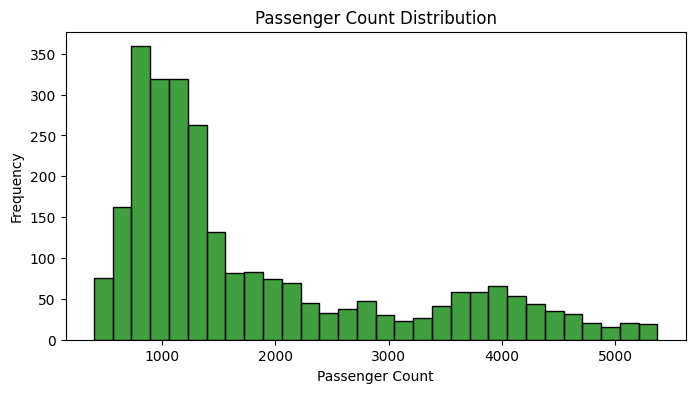

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,4))
sns.histplot(df['passenger_count'], bins=30, color='green')
plt.title('Passenger Count Distribution')
plt.xlabel('Passenger Count')
plt.ylabel('Frequency')
plt.show()

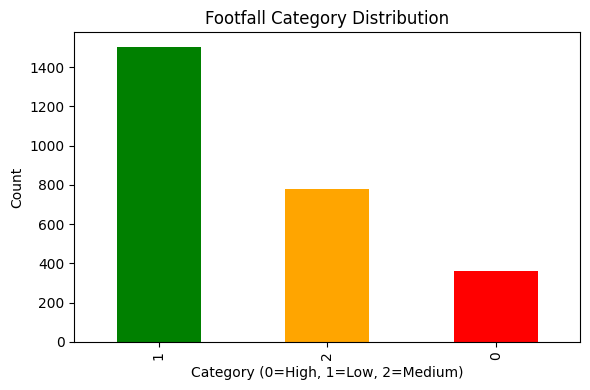

In [25]:
plt.figure(figsize=(6,4))
df['Passenger_Crowd_Level'].value_counts().plot(
    kind='bar', color=['green','orange','red']
)
plt.title('Footfall Category Distribution')
plt.xlabel('Category (0=High, 1=Low, 2=Medium)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# What to check:
# Is data balanced? (equal Low/Medium/High)
# Imbalanced data needs special treatment!

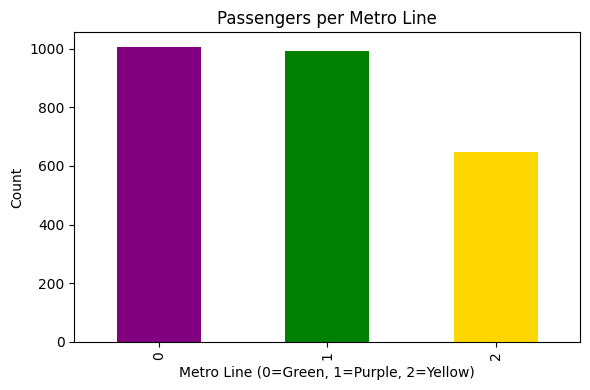

In [26]:
# ─────────────────────────────────────────
# Plot 3 — Metro Line Distribution
# ─────────────────────────────────────────
plt.figure(figsize=(6,4))
df['metro_line'].value_counts().plot(
    kind='bar', color=['purple','green','gold']
)
plt.title('Passengers per Metro Line')
plt.xlabel('Metro Line (0=Green, 1=Purple, 2=Yellow)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

C:\Users\nandh\AppData\Local\Temp\ipykernel_5864\3884832046.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


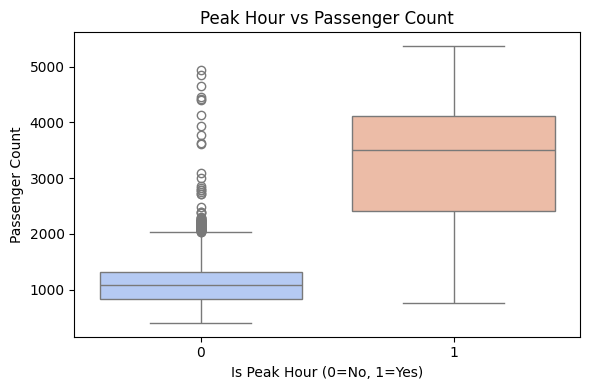

In [27]:

# ─────────────────────────────────────────
# Plot 4 — Peak Hour vs Passenger Count
# ─────────────────────────────────────────
plt.figure(figsize=(6,4))
sns.boxplot(
    x='is_peak_hour',
    y='passenger_count',
    data=df,
    palette='coolwarm'
)
plt.title('Peak Hour vs Passenger Count')
plt.xlabel('Is Peak Hour (0=No, 1=Yes)')
plt.ylabel('Passenger Count')
plt.tight_layout()
plt.show()

# What to check:
# Does peak hour really increase passengers?

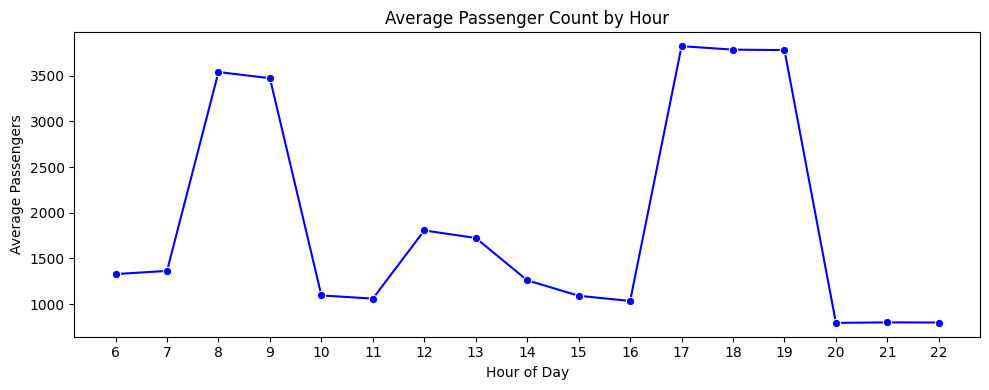

In [28]:
# ─────────────────────────────────────────
# Plot 5 — Hourly Passenger Trend
# ─────────────────────────────────────────
plt.figure(figsize=(10,4))
hourly = df.groupby('hour_of_day')['passenger_count'].mean()
sns.lineplot(
    x=hourly.index,
    y=hourly.values,
    color='blue',
    marker='o'
)
plt.title('Average Passenger Count by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Passengers')
plt.xticks(range(6,23))
plt.tight_layout()
plt.show()

# What to check:
# Which hours have most passengers?
# Morning peak? Evening peak?

C:\Users\nandh\AppData\Local\Temp\ipykernel_5864\241447884.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


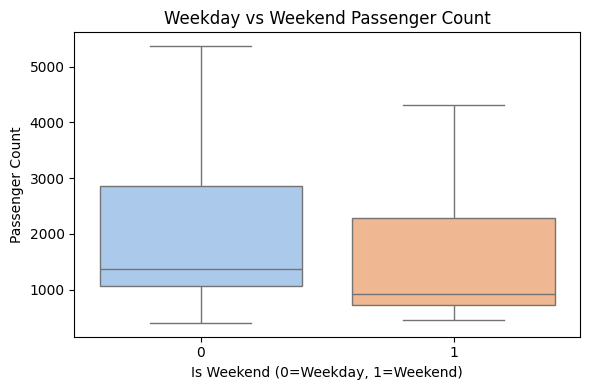

In [29]:
# ─────────────────────────────────────────
# Plot 6 — Weekend vs Weekday
# ─────────────────────────────────────────
plt.figure(figsize=(6,4))
sns.boxplot(
    x='is_weekend',
    y='passenger_count',
    data=df,
    palette='pastel'
)
plt.title('Weekday vs Weekend Passenger Count')
plt.xlabel('Is Weekend (0=Weekday, 1=Weekend)')
plt.ylabel('Passenger Count')
plt.tight_layout()
plt.show()

C:\Users\nandh\AppData\Local\Temp\ipykernel_5864\2440878672.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


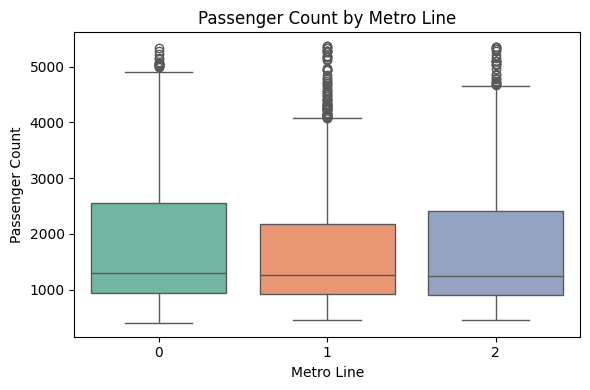

In [30]:
# ─────────────────────────────────────────
# Plot 7 — Metro Line vs Passenger Count
# ─────────────────────────────────────────
plt.figure(figsize=(6,4))
sns.boxplot(
    x='metro_line',
    y='passenger_count',
    data=df,
    palette='Set2'
)
plt.title('Passenger Count by Metro Line')
plt.xlabel('Metro Line')
plt.ylabel('Passenger Count')
plt.tight_layout()
plt.show()

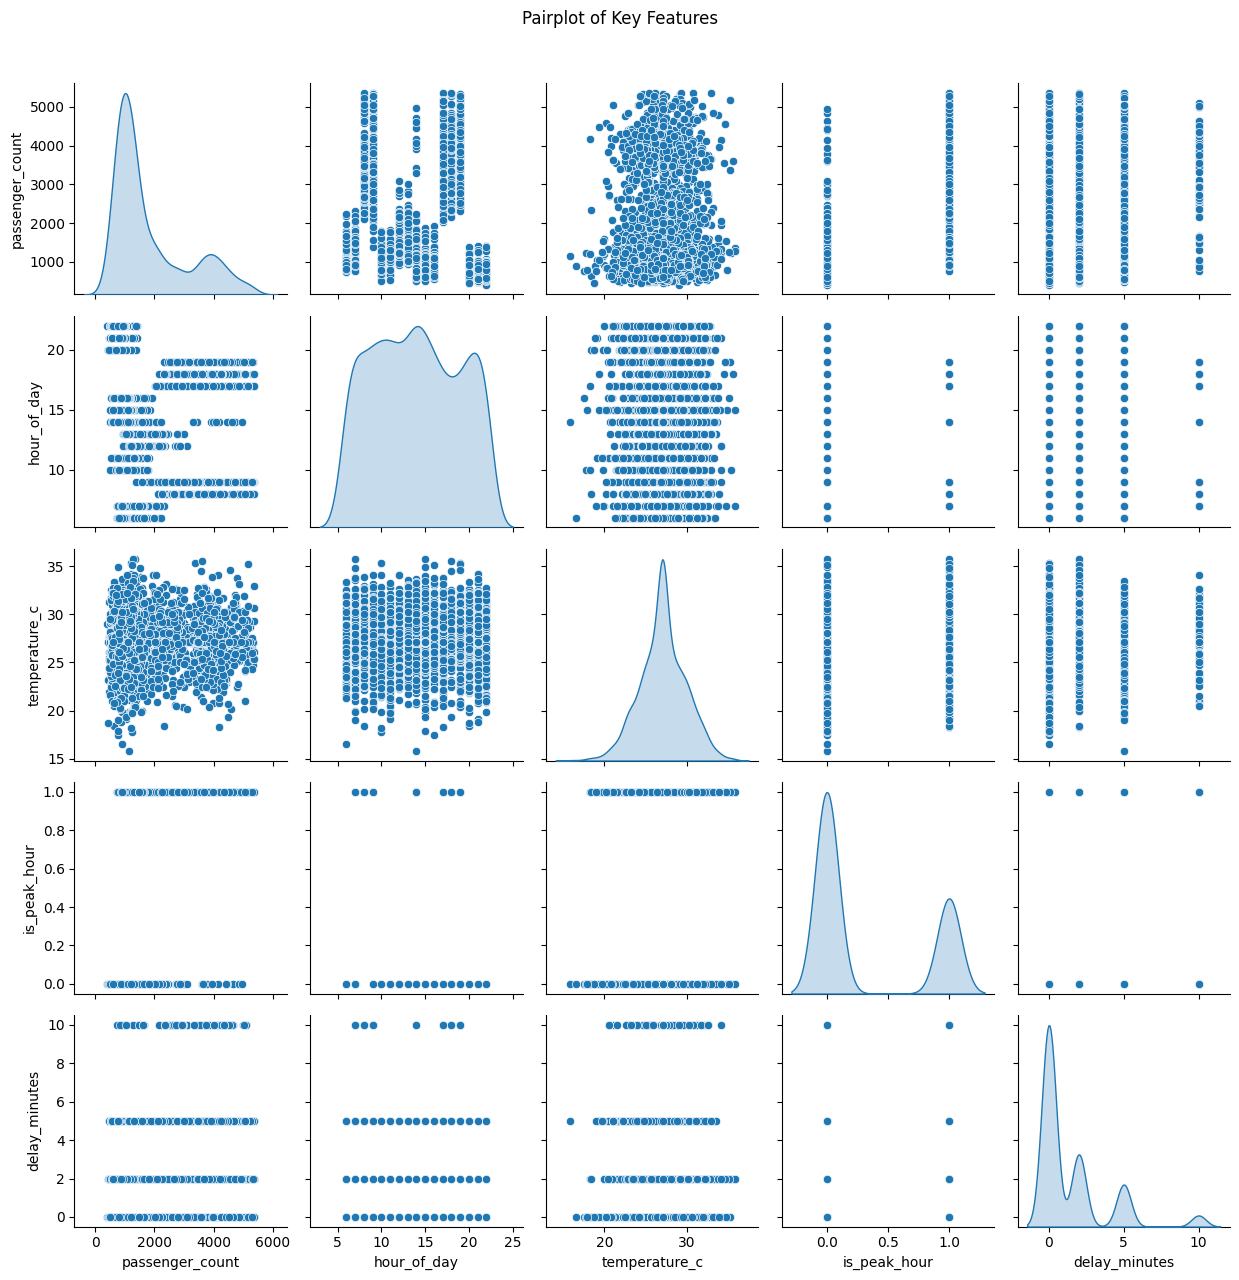

In [31]:
# ─────────────────────────────────────────
# Plot 10 — Pairplot (Key Features)
# ─────────────────────────────────────────
key_cols = [
    'passenger_count',
    'hour_of_day',
    'temperature_c',
    'is_peak_hour',
    'delay_minutes'
]

sns.pairplot(df[key_cols], diag_kind='kde')
plt.suptitle('Pairplot of Key Features', y=1.02)
plt.tight_layout()
plt.show()

# What to check:
# Relationships between multiple features
# at the same time!

In [32]:
# Check your numerical columns
print("Numerical columns:")
print(df.select_dtypes(include=['float64','int64']).columns.tolist())
print("\nBasic Stats:")
print(df.describe())

Numerical columns:
['station_name', 'metro_line', 'hour_of_day', 'day_of_week', 'month', 'is_weekend', 'is_holiday', 'temperature_c', 'is_raining', 'nearby_it_park', 'train_frequency_min', 'is_peak_hour', 'time_category', 'is_off_day', 'passenger_count', 'Passenger_Crowd_Level', 'station_type', 'delay_minutes', 'wifi_available', 'fare_inr']

Basic Stats:
       station_name   metro_line  hour_of_day  day_of_week        month  \
count   2643.000000  2643.000000  2643.000000  2643.000000  2643.000000   
mean      18.010594     0.864170    13.916005     2.990541     5.325766   
std       10.304775     0.778748     4.882393     1.975317     3.451651   
min        0.000000     0.000000     6.000000     0.000000     0.000000   
25%        9.000000     0.000000    10.000000     1.000000     2.000000   
50%       19.000000     1.000000    14.000000     3.000000     5.000000   
75%       27.000000     1.000000    18.000000     5.000000     8.000000   
max       35.000000     2.000000    22.0000

In [33]:
print("Column ranges:")
num_cols = ['temperature_c', 'fare_inr','train_frequency_min', 'delay_minutes','hour_of_day', 'passenger_count']
for col in num_cols:
    print(f"{col}: min={df[col].min():}, max={df[col].max():}")

Column ranges:
temperature_c: min=15.8, max=35.8
fare_inr: min=10.0, max=50.0
train_frequency_min: min=3.0, max=8.0
delay_minutes: min=0.0, max=10.0
hour_of_day: min=6, max=22
passenger_count: min=402.0, max=5370.0


## ⚖️ Feature Scaling

In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
scale_cols = ['temperature_c','fare_inr','train_frequency_min','delay_minutes','hour_of_day']
scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])
print("AFTER STANDARD SCALING:")
print(df[scale_cols].head())

AFTER STANDARD SCALING:
   temperature_c  fare_inr  train_frequency_min  delay_minutes  hour_of_day
0       1.977023 -1.477918             1.635637      -0.609419     1.246345
1      -0.351301 -0.405540            -0.036052       1.527914    -0.187649
2      -1.318451 -0.405540            -0.036052       0.245514     0.017207
3      -0.816966 -0.405540             1.635637      -0.609419     1.246345
4      -1.390091 -0.941729             1.635637      -0.609419     1.246345


C:\Users\nandh\AppData\Local\Temp\ipykernel_5864\836088131.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[scale_cols] = scaler.fit_transform(df[scale_cols])


## 🎯 Feature Selection

In [35]:
#Feature selection
x = df.drop(columns=['passenger_count','Passenger_Crowd_Level','date'])
y_reg = df['passenger_count']#Target
y_clf = df['Passenger_Crowd_Level']#Target

## ✂️ Train Test Split

In [36]:
import sklearn
from sklearn.model_selection import train_test_split
#regession
x_train_reg,x_test_reg,y_train_reg,y_test_reg=train_test_split(x,y_reg,test_size=0.2,random_state=42)
#classfication
x_train_clf,x_test_clf,y_train_clf,y_test_clf=train_test_split(x,y_clf,test_size=0.2,random_state=42)

In [37]:
# Add these prints to verify split
print("REGRESSION SPLIT:")
print(f"x_train_reg: {x_train_reg.shape}")
print(f"x_test_reg:  {x_test_reg.shape}")

print("CLASSIFICATION SPLIT:")
print(f"x_train_clf: {x_train_clf.shape}")
print(f"x_test_clf:  {x_test_clf.shape}")

REGRESSION SPLIT:
x_train_reg: (2114, 18)
x_test_reg:  (529, 18)
CLASSIFICATION SPLIT:
x_train_clf: (2114, 18)
x_test_clf:  (529, 18)


# 🤖 Model Building 

In [38]:
#LinearRegression
import numpy as np
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,f1_score,confusion_matrix,classification_report,mean_absolute_error,mean_squared_error
lr=LinearRegression()
lr.fit(x_train_reg,y_train_reg)
y_pred_lr = lr.predict(x_test_reg)
r2_lr  = r2_score(y_test_reg, y_pred_lr)
mae_lr = mean_absolute_error(y_test_reg, y_pred_lr)
rmse_lr  = np.sqrt(mean_squared_error(y_test_reg, y_pred_lr))
print("LINEAR REGRESSION:")
print(f"R² Score : {r2_lr:.4f}")
print(f"MAE      : {mae_lr:.2f}")
print(f"RMSE     : {rmse_lr:.2f}")

LINEAR REGRESSION:
R² Score : 0.7515
MAE      : 484.45
RMSE     : 647.57


In [39]:
from sklearn.ensemble import RandomForestRegressor
rf_reg = RandomForestRegressor(n_estimators=100,
    random_state=42
)
rf_reg.fit(x_train_reg, y_train_reg)
y_pred_rf = rf_reg.predict(x_test_reg)

r2_rf  = r2_score(y_test_reg, y_pred_rf)
mae_rf = mean_absolute_error(y_test_reg, y_pred_rf)
rmse_lr  = np.sqrt(mean_squared_error(y_test_reg, y_pred_lr))
print("RANDOM FOREST REGRESSOR:")
print(f"R² Score : {r2_rf:.4f}")
print(f"MAE      : {mae_rf:.2f}")
print(f"RMSE     : {rmse_rf:.2f}")

RANDOM FOREST REGRESSOR:
R² Score : 0.9635
MAE      : 157.13


NameError: name 'rmse_rf' is not defined

In [ ]:
from xgboost import XGBRegressor
xgb_reg = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
xgb_reg.fit(x_train_reg, y_train_reg)
y_pred_xgb = xgb_reg.predict(x_test_reg)

r2_xgb  = r2_score(y_test_reg, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test_reg, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test_reg, y_pred_xgb))

print("XGBOOST REGRESSOR:")
print(f"R² Score : {r2_xgb:.4f}")
print(f"MAE      : {mae_xgb:.2f}")
print(f"RMSE     : {rmse_xgb:.2f}")

In [ ]:
print("\n" + "="*50)
print("REGRESSION MODEL COMPARISON")
print("="*50)
print(f"{'Model':<25} {'R²':>8} {'MAE':>10} {'RMSE':>10}")
print("-"*50)
print(f"{'Linear Regression':<25} {r2_lr:>8.4f} {mae_lr:>10.2f} {rmse_lr:>10.2f}")
print(f"{'Random Forest':<25} {r2_rf:>8.4f} {mae_rf:>10.2f} {rmse_rf:>10.2f}")
print(f"{'XGBoost':<25} {r2_xgb:>8.4f} {mae_xgb:>10.2f} {rmse_xgb:>10.2f}")
print("="*50)

# Best model
best_r2 = max(r2_lr, r2_rf, r2_xgb)
if best_r2 == r2_lr:
    print("Best Model: Linear Regression")
elif best_r2 == r2_rf:
    print("Best Model: Random Forest")
else:
    print("Best Model: XGBoost")

In [ ]:
#classfication
import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,r2_score,f1_score,confusion_matrix,classification_report,mean_absolute_error,mean_squared_error

lc=LogisticRegression(max_iter=1000,random_state=42)
lc.fit(x_train_clf,y_train_clf)
y_pred_clf=lc.predict(x_test_clf)

acc_log = accuracy_score(y_test_clf, y_pred_clf)
print("LOGISTIC REGRESSION:")
print(f"Accuracy : {acc_log*100:.2f}%")
print(classification_report(y_test_clf, y_pred_clf))


In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier(n_estimators=100,random_state=42)
rf_clf.fit(x_train_clf, y_train_clf)
y_pred_rf_clf = rf_clf.predict(x_test_clf)

acc_rf_clf = accuracy_score(y_test_clf, y_pred_rf_clf)
print("RANDOM FOREST CLASSIFIER:")
print(f"Accuracy : {acc_rf_clf*100:.2f}%")
print(classification_report(y_test_clf, y_pred_rf_clf))

In [ ]:
from xgboost import XGBClassifier
xgb_clf = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
xgb_clf.fit(x_train_clf, y_train_clf)
y_pred_xgb_clf = xgb_clf.predict(x_test_clf)

acc_xgb_clf = accuracy_score(y_test_clf, y_pred_xgb_clf)
print("XGBOOST CLASSIFIER:")
print(f"Accuracy : {acc_xgb_clf*100:.2f}%")
print(classification_report(y_test_clf, y_pred_xgb_clf))

In [ ]:
print("\n" + "="*45)
print("CLASSIFICATION MODEL COMPARISON")
print("="*45)
print(f"{'Model':<25} {'Accuracy':>10}")
print("-"*45)
print(f"{'Logistic Regression':<25} {acc_log*100:>9.2f}%")
print(f"{'Random Forest':<25} {acc_rf_clf*100:>9.2f}%")
print(f"{'XGBoost':<25} {acc_xgb_clf*100:>9.2f}%")
print("="*45)

best_acc = max(acc_log, acc_rf_clf, acc_xgb_clf)
if best_acc == acc_log:
    print("Best Model: Logistic Regression")
elif best_acc == acc_rf_clf:
    print("Best Model: Random Forest")
else:
    print("Best Model: XGBoost")

In [ ]:
import pickle

# Save best regression model (XGBoost)
with open('model_regression.pkl', 'wb') as f:
    pickle.dump(xgb_reg, f)

# Save best classification model (XGBoost)
with open('model_classification.pkl', 'wb') as f:
    pickle.dump(xgb_clf, f)

print("Models saved successfully!")
print("model_regression.pkl    ✅")
print("model_classification.pkl ✅")

# 📌 Project Structure

## 1. Data Collection
- Loaded the Bengaluru Metro dataset.
- Explored the dataset and identified missing values.

## 2. Data Preprocessing
- Handled missing values.
- Converted categorical variables into numerical format.
- Performed feature engineering and data cleaning.

## 3. Exploratory Data Analysis (EDA)
- Analyzed passenger footfall patterns.
- Studied temperature, train frequency, and weekend effects.
- Visualized important trends and relationships.

## 4. Regression Model Development
Built and compared multiple regression models:
- Linear Regression
- Random Forest Regressor
- XGBoost Regressor

### Target
Predict the **Passenger Footfall**.

### Best Model
**XGBoost Regressor**

---

## 5. Classification Model Development
Built and compared multiple classification models:
- Logistic Regression
- Random Forest Classifier
- XGBoost Classifier

### Target
Predict the **Footfall Category**
(Low, Medium, High).

### Best Model
**XGBoost Classifier**

---

## 6. Model Saving
Saved the trained models using Pickle:

- `model_regression.pkl`
- `model_classification.pkl`

---

## 7. Streamlit Application
Developed an interactive Streamlit web application that allows users to:

- Input metro-related parameters.
- Predict passenger footfall.
- Predict footfall category.
- Display prediction results instantly.

---

# Conclusion

This project presents a machine learning-based solution for Bengaluru Metro passenger analysis. Different regression and classification algorithms were evaluated, and XGBoost achieved the best performance. The final models were deployed through a Streamlit application, providing an easy-to-use interface for predicting passenger footfall and classifying demand levels. This system can assist metro authorities in planning train frequency and improving operational efficiency.

---

# Future Enhancements

- Real-time metro data integration.
- Advanced forecasting using LSTM models.
- Interactive dashboards with Plotly.
- Cloud deployment using Streamlit Cloud.
- Incorporation of weather and event data for improved prediction accuracy.